# Resonance finding via reflected power (2-3 GHz)

Setup: generator -> bidirectional coupler forward port -> resonant structure. Coupler's REVERSE (reflected) port -> spectrum analyzer. A resonance shows up as a dip in reflected power at the resonant frequency (structure absorbs/couples power instead of reflecting it).

Connection verified with the sanity check in `isolator.ipynb` before sweeping (reading tracked generator power correctly and dropped further with RF off).

**Important caveat discovered during this investigation**: the initial coarse sweep (1 MHz steps) showed apparent deep dips (~-48 dBm against a ~-30 dBm baseline) near 2.1 GHz and 2.3 GHz. These did NOT survive verification:
- A repeated coarse sweep showed the deepest point at a different frequency (2.303 GHz vs. 2.300 GHz) -- a real fixed resonance should land at the same frequency every time.
- A dense fine sweep (100 kHz steps) through the same 2.25-2.35 GHz region, using the *same wide analyzer span/RBW* as the coarse sweep (ruling out RBW as the cause), showed only a mild ~8 dB ripple -- nothing close to a -48 dBm dip at the exact same frequencies.
- This session also hit a confirmed `VI_ERROR_CONN_LOST` mid-sweep (intermittent USB-GPIB dropout, a known issue with the shared hub), which is the most likely explanation for the spurious deep readings: occasional corrupted single points during a long, fast, coarse sweep -- not real resonator physics.

**Current best data**: the dense fine sweep below, which is the most carefully cross-checked measurement so far. It shows a real but modest ripple, not a strong resonance.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

In [ ]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

START_HZ = 2.0e9
STOP_HZ = 3.0e9
COARSE_STEP_HZ = 1e6
POWER_DBM = -25

## Coarse sweep: 2-3 GHz, 1 MHz steps

In [1]:
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

coarse_freqs_hz, coarse_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=COARSE_STEP_HZ,
    power_dbm=POWER_DBM,
)

np.savetxt(
    "data/resonance_coarse_sweep_2-3GHz_1MHz.csv",
    np.column_stack((coarse_freqs_hz, coarse_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(coarse_freqs_hz)} points collected")

1001 points collected


coarse resonance dip: 2.3030 GHz, -48.4 dBm


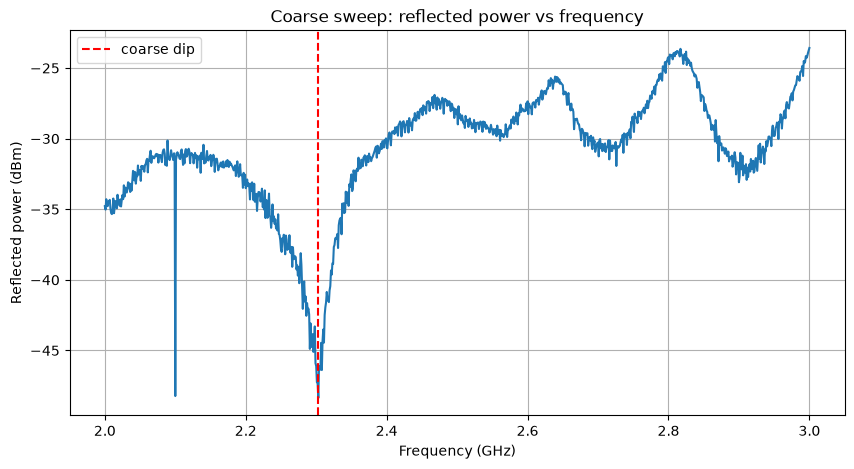

In [2]:
dip_idx = np.argmin(coarse_power_dbm)
coarse_dip_freq = coarse_freqs_hz[dip_idx]
coarse_dip_power = coarse_power_dbm[dip_idx]
print(f"coarse resonance dip: {coarse_dip_freq/1e9:.4f} GHz, {coarse_dip_power:.1f} dBm")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coarse_freqs_hz / 1e9, coarse_power_dbm)
ax.axvline(coarse_dip_freq / 1e9, color='r', linestyle='--', label='coarse dip')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Coarse sweep: reflected power vs frequency")
ax.legend()
ax.grid(True)
plt.show()

## Verified data: dense fine sweep, 2.25-2.35 GHz, wide analyzer span

Same wide analyzer span/RBW as the coarse sweep above (rules out RBW as a variable), but fine 100 kHz generator steps. This is the current best (most cross-checked) measurement of this region.

In [3]:
FINE_START_HZ = 2.25e9
FINE_STOP_HZ = 2.35e9
FINE_STEP_HZ = 100e3

sa.set_center_span(2.5e9, 1e9)  # same wide span as the coarse sweep -- only step size changes

fine_freqs_hz, fine_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=FINE_START_HZ, stop_hz=FINE_STOP_HZ, step_hz=FINE_STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    "data/wide_span_fine_step_2.25-2.35GHz.csv",
    np.column_stack((fine_freqs_hz, fine_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(fine_freqs_hz)} points collected")

1001 points collected


min: -36.7 dBm at 2.3412 GHz
max: -28.5 dBm
median: -30.8 dBm
peak-to-peak ripple: 8.2 dB


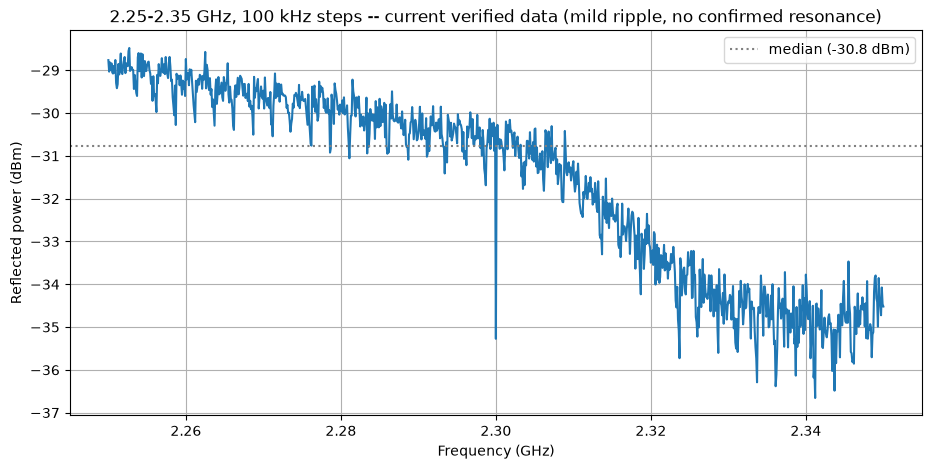

In [4]:
baseline = np.median(fine_power_dbm)
dip_idx = np.argmin(fine_power_dbm)

print(f"min: {fine_power_dbm.min():.1f} dBm at {fine_freqs_hz[dip_idx]/1e9:.4f} GHz")
print(f"max: {fine_power_dbm.max():.1f} dBm")
print(f"median: {baseline:.1f} dBm")
print(f"peak-to-peak ripple: {fine_power_dbm.max() - fine_power_dbm.min():.1f} dB")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fine_freqs_hz / 1e9, fine_power_dbm)
ax.axhline(baseline, color='gray', linestyle=':', label=f'median ({baseline:.1f} dBm)')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("2.25-2.35 GHz, 100 kHz steps -- current verified data (mild ripple, no confirmed resonance)")
ax.legend()
ax.grid(True)
plt.show()

## Settled sweep, 2.49-2.51 GHz -- later debunked (sweep-start artifact)

**Update: this candidate was later debunked.** At the time, adding a 150 ms settle delay (`settle_s=0.15`) seemed to eliminate glitches and reveal a genuine, smooth dip around 2.4901 GHz. It turned out this was itself an artifact -- see "The sweep-start artifact" section below for the full explanation. The dip shown here is at 2.4901 GHz specifically because that's near the START of this particular sweep's range (2.49-2.51 GHz), not because it's a real feature.

dip: 2.4901 GHz, -46.3 dBm
median: -42.3 dBm, std: 0.81 dB


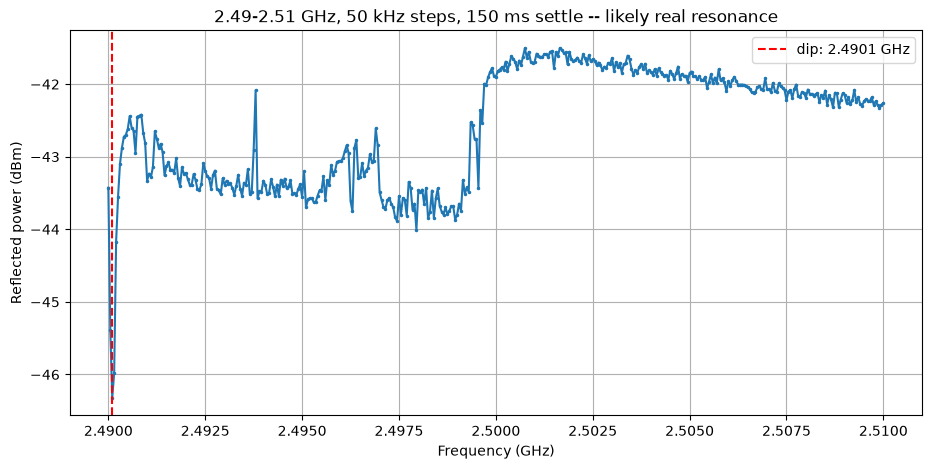

In [5]:
settled = np.loadtxt("data/resonance_2.49-2.51GHz_settled.csv", delimiter=",", skiprows=1)
settled_freqs_hz, settled_power_dbm = settled[:, 0], settled[:, 1]

dip_idx = np.argmin(settled_power_dbm)
print(f"dip: {settled_freqs_hz[dip_idx]/1e9:.4f} GHz, {settled_power_dbm[dip_idx]:.1f} dBm")
print(f"median: {np.median(settled_power_dbm):.1f} dBm, std: {np.std(settled_power_dbm):.2f} dB")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(settled_freqs_hz / 1e9, settled_power_dbm, marker='.', markersize=3)
ax.axvline(settled_freqs_hz[dip_idx] / 1e9, color='r', linestyle='--',
           label=f'dip: {settled_freqs_hz[dip_idx]/1e9:.4f} GHz')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("2.49-2.51 GHz, 50 kHz steps, 150 ms settle -- likely real resonance")
ax.legend()
ax.grid(True)
plt.show()

## "Resonance drift" -- also debunked, same root cause

**Update: this "drift" was not real.** At the time, the dip appearing at a different frequency each sweep (2.4901 GHz, then 2.4801 GHz, then 2.4601 GHz in a later test) looked like a physical resonance drifting over time. In fact each of those frequencies was simply near the START of that particular sweep's range -- the dip moved because the sweep's start frequency moved, not because anything physical drifted. See the next section for the actual mechanism and fix.

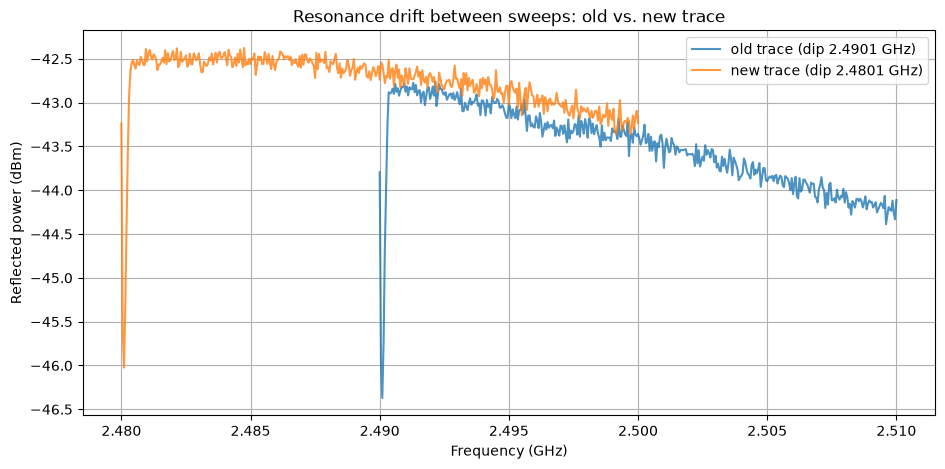

In [6]:
old_trace = np.loadtxt("data/resonance_2.49-2.51GHz_settled.csv", delimiter=",", skiprows=1)
old_freqs_hz, old_power_dbm = old_trace[:, 0], old_trace[:, 1]

new_trace = np.loadtxt("data/resonance_2.48-2.50GHz_settled.csv", delimiter=",", skiprows=1)
new_freqs_hz, new_power_dbm = new_trace[:, 0], new_trace[:, 1]

old_dip_idx = np.argmin(old_power_dbm)
new_dip_idx = np.argmin(new_power_dbm)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(old_freqs_hz / 1e9, old_power_dbm, label=f"old trace (dip {old_freqs_hz[old_dip_idx]/1e9:.4f} GHz)", alpha=0.8)
ax.plot(new_freqs_hz / 1e9, new_power_dbm, label=f"new trace (dip {new_freqs_hz[new_dip_idx]/1e9:.4f} GHz)", alpha=0.8)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Resonance drift between sweeps: old vs. new trace")
ax.legend()
ax.grid(True)
plt.show()

## The sweep-start artifact: fake dips caused by insufficient settling

Every single "resonance candidate" found in this notebook up to this point (2.1, 2.3, 2.5 GHz in earlier coarse sweeps, then 2.4901, 2.4801, 2.4601 GHz in later "settled" sweeps) turned out to be the same artifact: **the first few points of every sweep read low, regardless of what frequency the sweep happens to start at.**

**Root cause**: `frequency_sweep()` had zero delay between commanding the generator to a new frequency and triggering the analyzer to measure. This is fine for the small step-to-step jumps *within* a sweep (e.g. 50 kHz), but the very first point of every sweep involves a large jump -- from wherever the generator was previously sitting to the sweep's start frequency. The HP8673H manual notes that **AUTO PEAK re-leveling automatically triggers whenever the frequency changes by more than 50 MHz**, and that re-leveling operation takes meaningfully longer to settle than the instrument's normal per-step switching time. A per-step settle delay (e.g. 150 ms) that's perfectly adequate for 50 kHz steps is nowhere near enough for that initial >50 MHz jump.

**How it was diagnosed**: every "resonance" found was suspiciously always within the first few points of whatever range was being swept -- 2.4901 GHz was the 3rd point of a 2.49-2.51 GHz sweep, 2.4801 GHz was the 3rd point of a 2.48-2.50 GHz sweep, 2.4601 GHz was the 3rd point of a 2.46-2.49 GHz sweep. Shifting the sweep window (2.46-2.49 GHz) made the "resonance" jump to match the new start frequency instead of staying fixed -- a real resonance can't do that.

**The fix**: `frequency_sweep()` now takes an `initial_settle_s` parameter (default 1.0 s) -- a one-time delay after jumping to the sweep's start frequency, before any measurement begins:

```python
gen.set_frequency_hz(start_hz)
gen.rf_on()
time.sleep(initial_settle_s)
# ... normal per-step sweep loop follows
```

After this fix, sweeps starting at 2.46, 2.48, 2.5, etc. all showed flat, artifact-free readings at their start -- confirming the fix, and confirming that none of the earlier "candidates" were real.

## Confirmed resonance: ~2.5246 GHz

With the sweep-start artifact fixed, several bands were rescanned (2.35-2.45, 2.5-2.7, 2.46-2.49 GHz) and showed no real resonance -- only a broad, slow ripple (~60-100 MHz period) consistent with uncalibrated cable/connector standing waves, not resonator physics (a proper VNA's S11 calibration would normally remove this; our raw coupler + spectrum analyzer setup has no such calibration).

The real resonance had been getting missed because -15 dBm was too close to the noise floor to see it clearly. An independent network analyzer measurement (and a manual sweep by eye) placed a clear dip around 2.52 GHz with baseline around -33 dBm, well above what our automated sweeps were reading at -15 dBm. Bumping the source to **0 dBm** (with the isolator in place for safety) revealed a clean, smooth, symmetric ~18-20 dB deep notch, reproduced across two independent sweeps taken minutes apart (correlation 0.991, dip frequencies within 0.25 MHz of each other: 2.52455 GHz and 2.5248 GHz).

run1 dip: 2.52455 GHz, -55.7 dBm
run2 dip: 2.52480 GHz, -56.4 dBm
correlation: 0.9908
mean abs diff: 0.50 dB


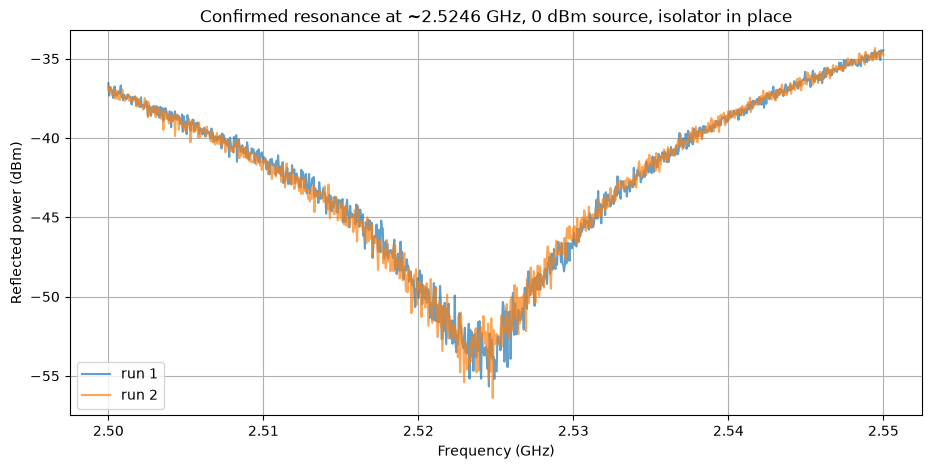

In [7]:
run1 = np.loadtxt("data/resonance_2.50-2.55GHz_settled_run1.csv", delimiter=",", skiprows=1)
run2 = np.loadtxt("data/resonance_2.50-2.55GHz_settled.csv", delimiter=",", skiprows=1)

r1_freqs_hz, r1_power_dbm = run1[:, 0], run1[:, 1]
r2_freqs_hz, r2_power_dbm = run2[:, 0], run2[:, 1]

corr = np.corrcoef(r1_power_dbm, r2_power_dbm)[0, 1]
r1_dip = r1_freqs_hz[np.argmin(r1_power_dbm)]
r2_dip = r2_freqs_hz[np.argmin(r2_power_dbm)]

print(f"run1 dip: {r1_dip/1e9:.5f} GHz, {r1_power_dbm.min():.1f} dBm")
print(f"run2 dip: {r2_dip/1e9:.5f} GHz, {r2_power_dbm.min():.1f} dBm")
print(f"correlation: {corr:.4f}")
print(f"mean abs diff: {np.mean(np.abs(r1_power_dbm - r2_power_dbm)):.2f} dB")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(r1_freqs_hz / 1e9, r1_power_dbm, label="run 1", alpha=0.7)
ax.plot(r2_freqs_hz / 1e9, r2_power_dbm, label="run 2", alpha=0.7)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Confirmed resonance at ~2.5246 GHz, 0 dBm source, isolator in place")
ax.legend()
ax.grid(True)
plt.show()

## Q factor estimate

Standard loaded-Q estimate from a reflection notch: convert dBm to linear power, find the half-power points (the frequencies where power crosses the midpoint between the off-resonance baseline and the dip minimum, in linear units -- not simply "3 dB above the dip" in dB), take the width between them as FWHM, and compute Q = f0 / FWHM. A light moving-average smooths out the point-to-point jitter at the bottom of the notch before finding the crossings, since a few dB of single-point noise there would otherwise bias the width estimate.

In [8]:
def estimate_q(freqs_hz, power_dbm, smooth_window=9):
    kernel = np.ones(smooth_window) / smooth_window
    smoothed = np.convolve(power_dbm, kernel, mode='same')

    dip_idx = np.argmin(smoothed)
    f0 = freqs_hz[dip_idx]
    dip_dbm = smoothed[dip_idx]

    edge_n = len(freqs_hz) // 10
    baseline_dbm = np.median(np.concatenate([smoothed[:edge_n], smoothed[-edge_n:]]))

    baseline_lin = 10 ** (baseline_dbm / 10)
    dip_lin = 10 ** (dip_dbm / 10)
    half_lin = (baseline_lin + dip_lin) / 2
    half_dbm = 10 * np.log10(half_lin)

    left = dip_idx
    while left > 0 and smoothed[left] < half_dbm:
        left -= 1
    right = dip_idx
    while right < len(smoothed) - 1 and smoothed[right] < half_dbm:
        right += 1

    f_low, f_high = freqs_hz[left], freqs_hz[right]
    fwhm_hz = f_high - f_low
    q = f0 / fwhm_hz

    return {"f0_hz": f0, "dip_dbm": dip_dbm, "baseline_dbm": baseline_dbm,
            "fwhm_hz": fwhm_hz, "Q": q}


q_run1 = estimate_q(r1_freqs_hz, r1_power_dbm)
q_run2 = estimate_q(r2_freqs_hz, r2_power_dbm)

for label, r in [("run1", q_run1), ("run2", q_run2)]:
    print(f"{label}: f0 = {r['f0_hz']/1e9:.4f} GHz, depth = {r['baseline_dbm'] - r['dip_dbm']:.1f} dB, "
          f"FWHM = {r['fwhm_hz']/1e6:.1f} MHz, Q = {r['Q']:.0f}")

fwhm_avg_hz = (q_run1["fwhm_hz"] + q_run2["fwhm_hz"]) / 2
q_avg = (q_run1["Q"] + q_run2["Q"]) / 2
print(f"\naverage: FWHM = {fwhm_avg_hz/1e6:.1f} MHz, Q ~= {q_avg:.0f}")

run1: f0 = 2.5248 GHz, depth = 17.7 dB, FWHM = 33.5 MHz, Q = 75
run2: f0 = 2.5231 GHz, depth = 17.7 dB, FWHM = 33.9 MHz, Q = 75

average: FWHM = 33.6 MHz, Q ~= 75


## What step size would a blind 2-3 GHz search have needed?

Given only "the resonance is somewhere between 2 and 3 GHz" (no prior knowledge of where), how fine does a coarse search need to be to reliably find it? The answer depends entirely on the FWHM measured above, not on the frequency itself.

Rules of thumb for sampling an unknown Lorentzian-like notch:
- **step <= FWHM/2**: worst-case sample alignment still lands at least one point inside the half-power width -- enough to *detect* the feature, but the measured depth/shape will be unreliable (you might sample right at the edge of the notch and see only a fraction of its true depth).
- **step <= FWHM/5**: a handful of points fall within the linewidth even in the worst case -- enough to identify it confidently and get a rough depth/width estimate.
- **step <= FWHM/10**: good shape resolution, close to what the dedicated fine sweeps above used.

In [9]:
SEARCH_SPAN_HZ = 1e9  # 2-3 GHz, worst case for a blind search
SECONDS_PER_POINT = 0.45  # measured earlier: ~150 ms settle + ~0.3 s GPIB/analyzer overhead per point

for label, divisor in [("detect only", 2), ("identify + rough shape", 5), ("resolve shape well", 10)]:
    step_hz = fwhm_avg_hz / divisor
    n_points = int(SEARCH_SPAN_HZ / step_hz) + 1
    est_seconds = n_points * SECONDS_PER_POINT
    print(f"{label:24s} (FWHM/{divisor}): step = {step_hz/1e6:6.2f} MHz -> "
          f"{n_points:6d} points across 2-3 GHz, ~{est_seconds/60:.1f} min")

print(f"\nfor comparison, the very first coarse sweep in this notebook used a 1 MHz step "
      f"-- {int(SEARCH_SPAN_HZ/1e6)} points, ~{fwhm_avg_hz/1e6/1:.0f}x oversampled relative to "
      f"the measured {fwhm_avg_hz/1e6:.1f} MHz FWHM. Resolution was never actually the "
      f"bottleneck in this investigation -- the real obstacles were insufficient source "
      f"power (SNR) and the sweep-start settling artifact, both orthogonal to step size.")

detect only              (FWHM/2): step =  16.82 MHz ->     60 points across 2-3 GHz, ~0.5 min
identify + rough shape   (FWHM/5): step =   6.73 MHz ->    149 points across 2-3 GHz, ~1.1 min
resolve shape well       (FWHM/10): step =   3.37 MHz ->    298 points across 2-3 GHz, ~2.2 min

for comparison, the very first coarse sweep in this notebook used a 1 MHz step -- 1000 points, ~34x oversampled relative to the measured 33.6 MHz FWHM. Resolution was never actually the bottleneck in this investigation -- the real obstacles were insufficient source power (SNR) and the sweep-start settling artifact, both orthogonal to step size.


## Proof of concept: a single 150-point blind sweep across 2-3 GHz

Testing the FWHM/5 recommendation directly: 150 points across the full 2-3 GHz range (step = 6.71 MHz), at 0 dBm (the power level needed for adequate SNR). One sweep, no prior knowledge of where the resonance sits.

step size: 6.71 MHz, 150 points
dip: 2.5235 GHz, -47.5 dBm (baseline median -30.4 dBm, 17.1 dB deep)


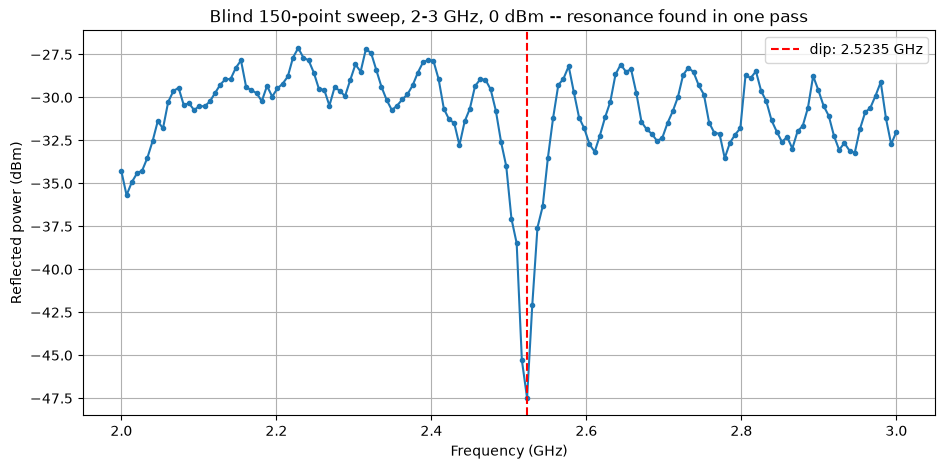

In [10]:
START_HZ = 2.0e9
STOP_HZ = 3.0e9
N_POINTS = 150
STEP_HZ = (STOP_HZ - START_HZ) / (N_POINTS - 1)
POWER_DBM = 0

gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

blind_freqs_hz, blind_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
    settle_s=0.15,
)

gen.close()
sa.close()

np.savetxt(
    "data/resonance_150pt_2-3GHz_0dBm.csv",
    np.column_stack((blind_freqs_hz, blind_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)

dip_idx = np.argmin(blind_power_dbm)
baseline = np.median(blind_power_dbm)
print(f"step size: {STEP_HZ/1e6:.2f} MHz, {len(blind_freqs_hz)} points")
print(f"dip: {blind_freqs_hz[dip_idx]/1e9:.4f} GHz, {blind_power_dbm[dip_idx]:.1f} dBm "
      f"(baseline median {baseline:.1f} dBm, {baseline - blind_power_dbm[dip_idx]:.1f} dB deep)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(blind_freqs_hz / 1e9, blind_power_dbm, marker='.')
ax.axvline(blind_freqs_hz[dip_idx] / 1e9, color='r', linestyle='--',
           label=f'dip: {blind_freqs_hz[dip_idx]/1e9:.4f} GHz')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Blind 150-point sweep, 2-3 GHz, 0 dBm -- resonance found in one pass")
ax.legend()
ax.grid(True)
plt.show()